In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [14]:
data = pd.read_csv(r"C:\Users\mulyam\Documents\python_project\Sample - Superstore.csv",encoding="latin1")

# basic understanding of data

In [15]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
data.shape

(9994, 21)

In [17]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [19]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [20]:
# Null value check
data.isna().sum().sum()

np.int64(0)

#### Fix The Data Types   

In [21]:
data['Order Date']=data['Order Date'].astype('datetime64[ns]')
data['Ship Date']=data['Ship Date'].astype('datetime64[ns]')

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

#### Extracted Year, Month, And Day From The Order Date

In [23]:
data['Order_year']=data['Order Date'].dt.year
data['Order_month']=data['Order Date'].dt.month
data['Order_day']=data['Order Date'].dt.day
# MARGIN
data['margin'] = data['Profit']/data['Sales']

#### Cost Coloumn Create

In [24]:
data['cost'] = data['Sales']-data['Profit']

In [25]:
data.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order_year,Order_month,Order_day,margin,cost
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,11,8,0.16,220.0464
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,11,8,0.30,512.3580


## Data Analysis With visualization

### SALES AND PROFIT PER YEAR

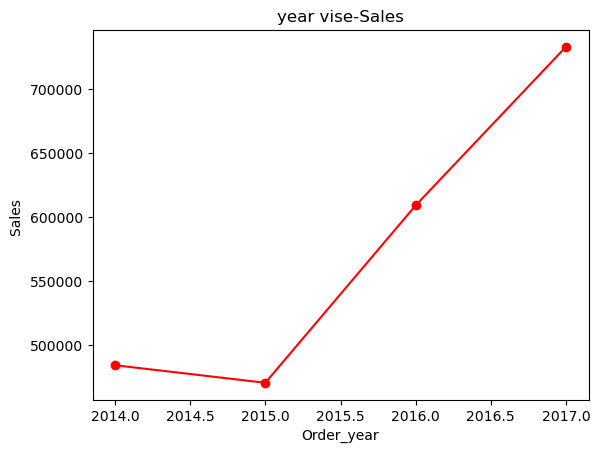

In [42]:
yearly_sales = data.groupby('Order_year')['Sales'].sum()
yearly_sales.plot(kind='line',c = 'r',marker='o')

plt.title('year vise-Sales')
plt.xlabel('Order_year')
plt.ylabel('Sales ')
plt.show()



In [83]:
## The highest sales in 2017(Year)

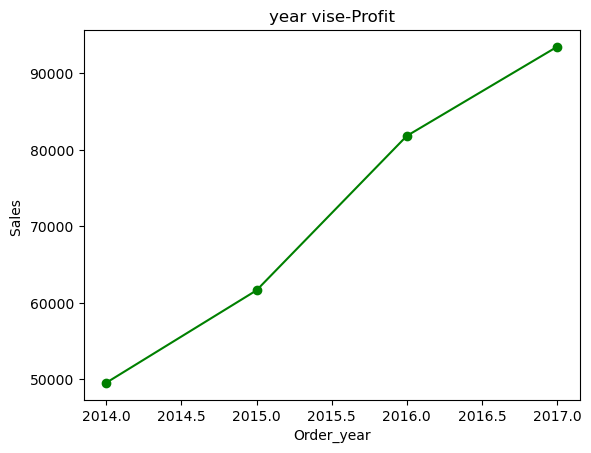

In [34]:
yearly_profit = data.groupby('Order_year')['Profit'].sum()
yearly_profit.plot(kind='line',c = 'g',marker='o')

plt.title('year vise-Profit')
plt.xlabel('Order_year')
plt.ylabel('Sales ')

plt.show()

In [82]:
## The highest Profit in 2017(Year)

### SALES PER MONTH

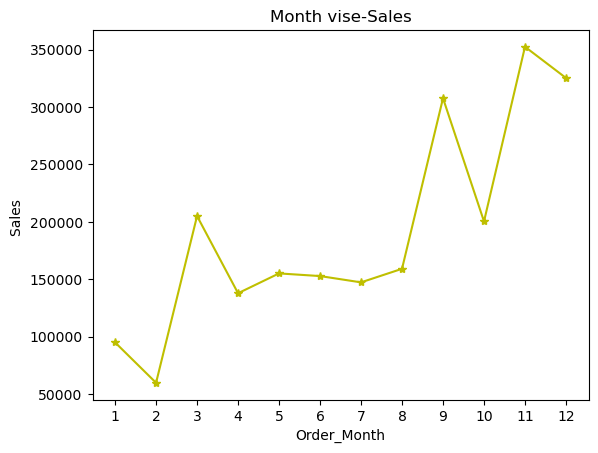

In [50]:
monthly_sales = data.groupby('Order_month')['Sales'].sum()
monthly_sales.plot(kind='line',c = 'y',marker='*')
plt.xticks(range(1,13))
plt.title('Month vise-Sales')
plt.xlabel('Order_Month')
plt.ylabel('Sales ')
plt.show()

In [ ]:
## The highest sales in November(Month)

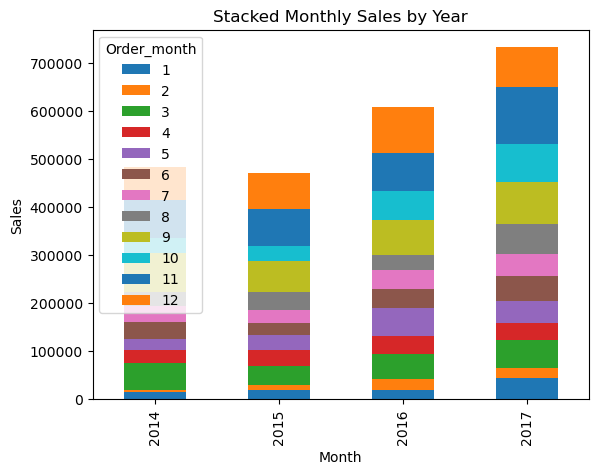

In [53]:
year_monthly_sales = data.groupby(['Order_year','Order_month'])['Sales'].sum()
year_monthly_sales.unstack().plot(kind='bar', stacked=True)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Stacked Monthly Sales by Year")

plt.show()

### Sales By Sub_Catgory

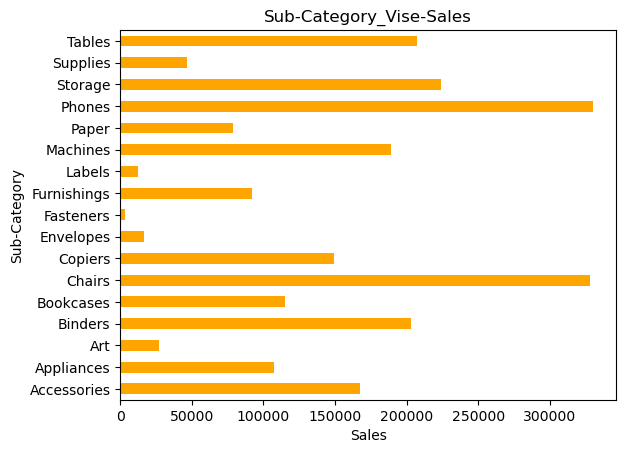

In [66]:
sub_category_sales = data.groupby('Sub-Category')['Sales'].sum()
sub_category_sales.plot(kind='barh',color = 'orange')

plt.title('Sub-Category_Vise-Sales')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
#ax.bar_label(ax.containers[0])(bar ke uper value dikhani hai to)
plt.show()

In [ ]:
# Phones have the highest sales across all categories.

### sales by region

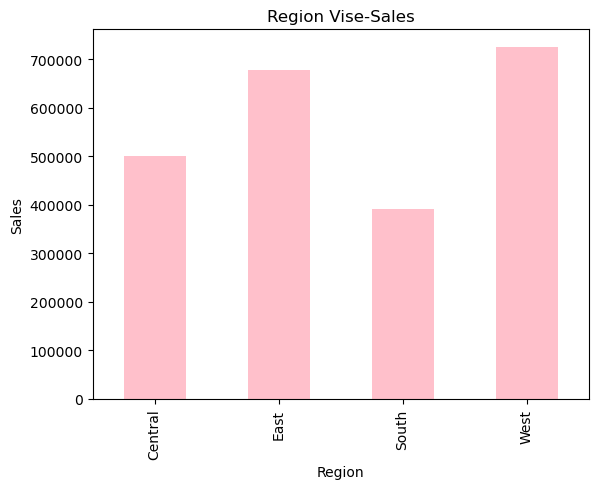

In [69]:
region_sales = data.groupby('Region')['Sales'].sum()
region_sales.plot(kind='bar',color = 'pink')

plt.title('Region Vise-Sales')
plt.xlabel('Region')
plt.ylabel('Sales')
#ax.bar_label(ax.containers[0])(bar ke uper value dikhani hai to)
plt.show()

In [ ]:
## The highest Sales in West zone

### top 10 sellings products

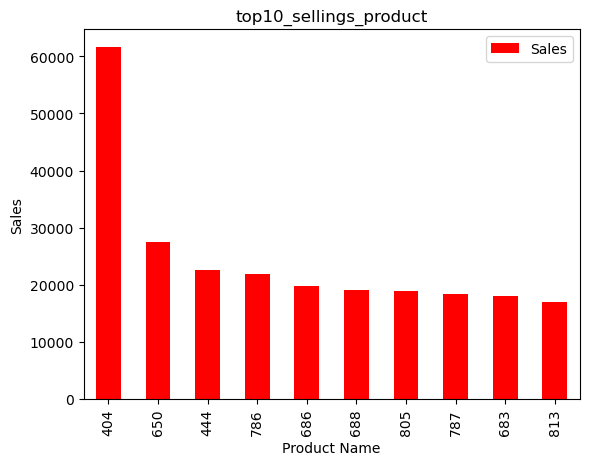

In [70]:
top10_sellings_product = data.groupby('Product Name')['Sales'].sum().reset_index().nlargest(10,"Sales")
top10_sellings_product.plot(kind='bar',color = 'red')

plt.title('top10_sellings_product')
plt.xlabel('Product Name')
plt.ylabel('Sales')
#ax.bar_label(ax.containers[0])(bar ke uper value dikhani hai to)
plt.show()

In [50]:
top10_sellings_product

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


### top 5 sub_catgory sales

<function matplotlib.pyplot.show(close=None, block=None)>

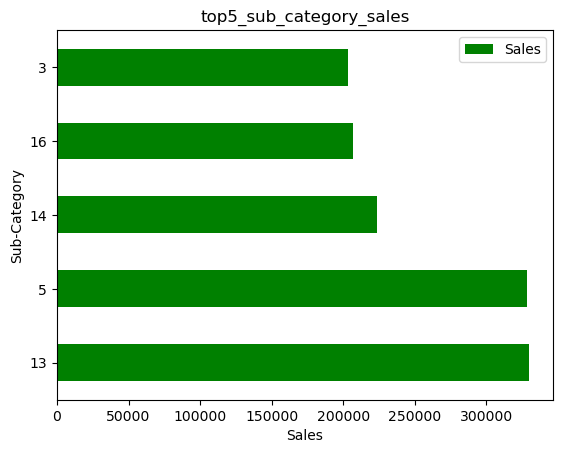

In [71]:
top5_sub_category_sales = data.groupby('Sub-Category')['Sales'].sum().reset_index().nlargest(5,"Sales")
top5_sub_category_sales.plot(kind='barh',color = 'green')

plt.title('top5_sub_category_sales')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.show

In [53]:
top5_sub_category_sales

,Sub-Category,Sales
13,Phones,330007.054
5,Chairs,328449.103
14,Storage,223843.608
16,Tables,206965.532
3,Binders,203412.733


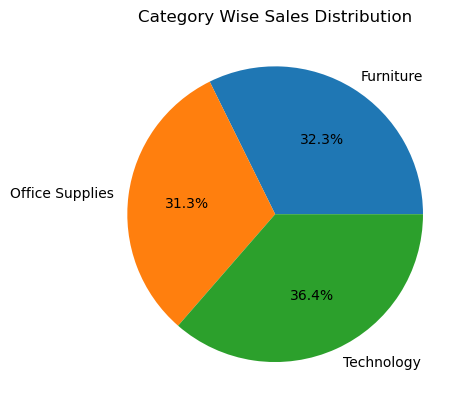

In [78]:
catgory_sales = data.groupby('Category')['Sales'].sum()
catgory_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title('Category Wise Sales Distribution')

plt.ylabel('')  # Y-axis hata deta hai
plt.show()

In [ ]:
# ## The highest Sales in Technology(Catgory)

### Advance Data Analysis

In [79]:
# average profit margin by category
category_margin = data.groupby('Category')['margin'].mean()

In [80]:
category_margin

Category
Furniture          0.038784
Office Supplies    0.138030
Technology         0.156138
Name: margin, dtype: float64

In [54]:
month_catgory = data.groupby(['Order_month','Category'])['Sales'].sum().reset_index()

In [55]:
month_catgory

,Order_month,Category,Sales
0,1,Furniture,31569.2416
1,1,Office Supplies,33233.8310
2,1,Technology,30121.7630
3,2,Furniture,15765.9204
4,2,Office Supplies,20641.9130
5,2,Technology,23343.4180
6,3,Furniture,50768.2758
7,3,Office Supplies,56385.6430
8,3,Technology,97851.5700
9,4,Furniture,40698.5836


In [56]:
# har month ki top catgory sales
month_top_catgory = month_catgory.loc[month_catgory.groupby('Order_month')['Sales'].idxmax()]

In [57]:
month_top_catgory

,Order_month,Category,Sales
1,1,Office Supplies,33233.8310
5,2,Technology,23343.4180
8,3,Technology,97851.5700
10,4,Office Supplies,49433.2700
14,5,Technology,63642.1550
15,6,Furniture,52999.4633
20,7,Technology,54854.0260
22,8,Office Supplies,62134.1620
24,9,Furniture,106380.5907
29,10,Technology,87031.9450


In [85]:
###

In [59]:
year_month_catgory = data.groupby(['Order_year','Order_month','Category'])['Sales'].sum().reset_index()

In [60]:
yerly_monthly_top = year_month_catgory.loc[year_month_catgory.groupby(['Order_year','Order_month'])['Sales'].idxmax()]

In [61]:
yerly_monthly_top

,Order_year,Order_month,Category,Sales
0,2014,1,Furniture,6242.5250
3,2014,2,Furniture,1839.6580
8,2014,3,Technology,32511.1740
10,2014,4,Office Supplies,11155.0740
14,2014,5,Technology,9599.8760
15,2014,6,Furniture,13206.1256
19,2014,7,Office Supplies,15121.2080
22,2014,8,Office Supplies,11379.4620
26,2014,9,Technology,30537.5720
27,2014,10,Furniture,12304.2470


In [62]:
##   (yearly ki monthly bases par compare karna catgory wise sales)
#### 2014(march) me Technology(catgory) ki sabse jyada sales hui hai or 2014(january) me (furniture) ki sabse lowest sales hui hai
#### 2015(december) me Technology(catgory) ki sabse jyada sales hui hai or 2015(february) me (Office Supplies) ki sabse lowest sales hui hai
#### 2016(december) me Office Supplies(catgory) ki sabse jyada sales hui hai or 2016(january) me (furniture) ki sabse lowest sales hui hai
#### 2017(november) me Technology(catgory) ki sabse jyada sales hui hai or 2017(february) me (Office Supplies) ki sabse lowest sales hui hai

In [64]:
data.groupby('Order_year')['cost'].sum()

Order_year
2014    434703.5240
2015    408913.9053
2016    527410.4237
2017    639775.9856
Name: cost, dtype: float64

In [66]:
data.groupby('Category')['cost'].sum()

Category
Furniture          723548.5225
Office Supplies    596556.2312
Technology         690699.0849
Name: cost, dtype: float64

In [67]:
data.groupby(['Order_year','Category'])['cost'].sum()

Order_year  Category       
2014        Furniture          151735.1276
            Office Supplies    129182.9959
            Technology         153785.4005
2015        Furniture          167503.0341
            Office Supplies    112133.9292
            Technology         129276.9420
2016        Furniture          191941.4829
            Office Supplies    148878.7528
            Technology         186590.1880
2017        Furniture          212368.8779
            Office Supplies    206360.5533
            Technology         221046.5544
Name: cost, dtype: float64

#### '“In this dataset, I cleaned, transformed, and analyzed the data to extract meaningful insights.'